Isolation Forest:

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# Load the dataset
df = pd.read_csv("C://Users//israt//HD lab//My Project//Dataset//Airsage Dataset//NebraskaLakes_Cleaned_round.csv")

# Basic preprocessing
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
df = df.dropna(subset=['count', 'duration'])

# Add day name and day type (Weekday or Weekend)
df['day_of_week'] = df['date'].dt.day_name()
df['day_type'] = df['date'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')


print(f"Total number of rows: {len(df)}")

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['count', 'duration']])

# Apply Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
df['anomaly_label'] = iso_forest.fit_predict(X_scaled)  # -1 = anomaly, 1 = normal

# Convert label: 1 -> 0 (normal), -1 -> 1 (anomaly)
df['anomaly_label'] = df['anomaly_label'].map({1: 0, -1: 1})

# Anomaly scores: flip decision_function so higher = more anomalous
df['anomaly_score'] = -iso_forest.decision_function(X_scaled)

# Print all rows with scores
#print("All points with anomaly scores (Isolation Forest):")
#print(df[['poi', 'date', 'count', 'duration', 'anomaly_label', 'anomaly_score']])
print(f"Total number of anomalies detected: {df['anomaly_label'].sum()}")
print(f"Total number of normal points: {(df['anomaly_label'] == 0).sum()}") 






C:\Users\israt\AppData\Local\Temp\ipykernel_26284\1725214512.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C://Users//israt//HD lab//My Project//Dataset//Airsage Dataset//NebraskaLakes_Cleaned_round.csv")


Total number of rows: 123627
Total number of anomalies detected: 12362
Total number of normal points: 111265


In [2]:
top_by_score = df.sort_values(by='anomaly_score', ascending=False).head(20)
print("\nTop points by raw anomaly score (regardless of label):")
print(top_by_score[['poi', 'date', 'day_type', 'count', 'duration', 'anomaly_label']])



Top points by raw anomaly score (regardless of label):
                    poi       date day_type   count    duration  anomaly_label
32434            Holmes 2022-05-04  Weekday  2970.0  155.472078              1
31733  Glenn Cunningham 2022-05-31  Weekday  2975.0  185.583333              1
32471            Holmes 2022-05-09  Weekday  2939.0  168.278229              1
32464            Holmes 2022-05-08  Weekend  2856.0  156.809850              1
32480            Holmes 2022-05-10  Weekday  2845.0  177.921468              1
32554            Holmes 2022-05-21  Weekend  2779.0  154.430766              1
32451            Holmes 2022-05-06  Weekday  2749.0  158.087151              1
32442            Holmes 2022-05-05  Weekday  2753.0  169.791736              1
32417            Holmes 2022-05-02  Weekday  2703.0  139.296528              1
32524            Holmes 2022-05-17  Weekday  2698.0  130.560173              1
28815       Carter Lake 2022-05-31  Weekday  2615.0  134.247475            

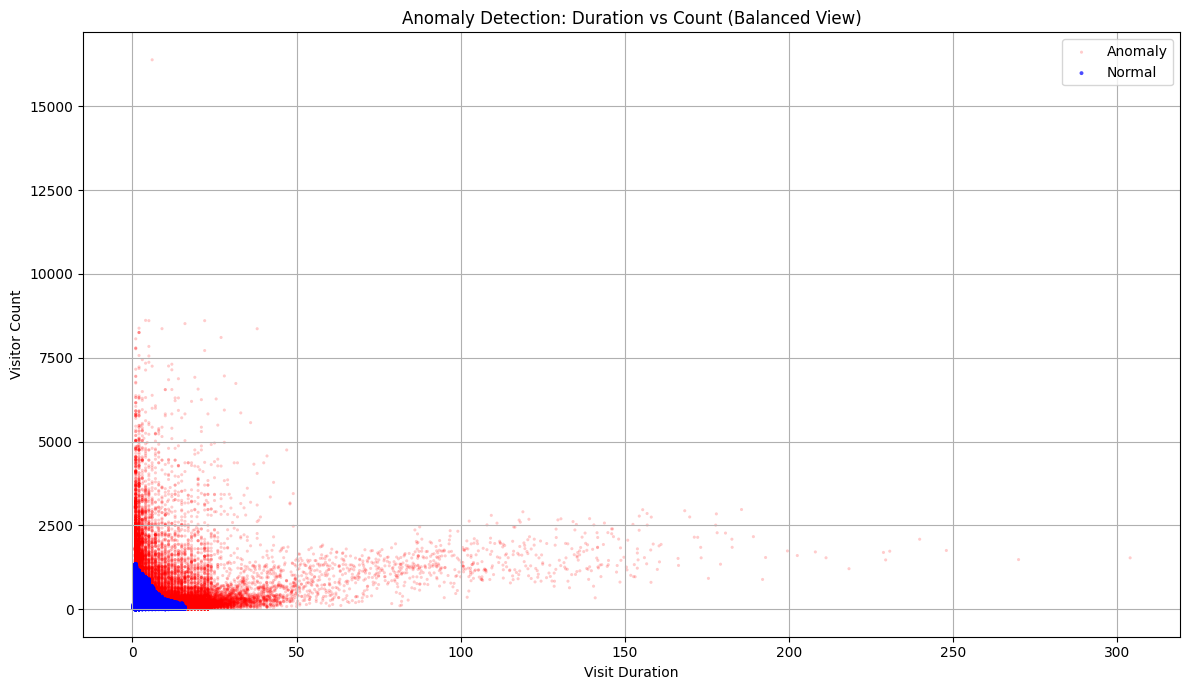

In [3]:
import matplotlib.pyplot as plt

# Separate normal and anomaly points
anomalies = df[df['anomaly_label'] == 1]
normal = df[df['anomaly_label'] == 0]

plt.figure(figsize=(12, 7))

# 1. Plot anomalies with small, light red markers
plt.scatter(anomalies['duration'], anomalies['count'],
            c='red', label='Anomaly', alpha=0.2, s=5, edgecolor='none')

# 2. Plot normal points last, so they appear on top
plt.scatter(normal['duration'], normal['count'],
            c='blue', label='Normal', alpha=0.7, s=8, edgecolor='none')

# Optional: Apply log scale to better distribute values
#plt.xscale('log')
#plt.yscale('log')

# Titles and labels
plt.xlabel('Visit Duration')
plt.ylabel('Visitor Count')
plt.title('Anomaly Detection: Duration vs Count (Balanced View)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


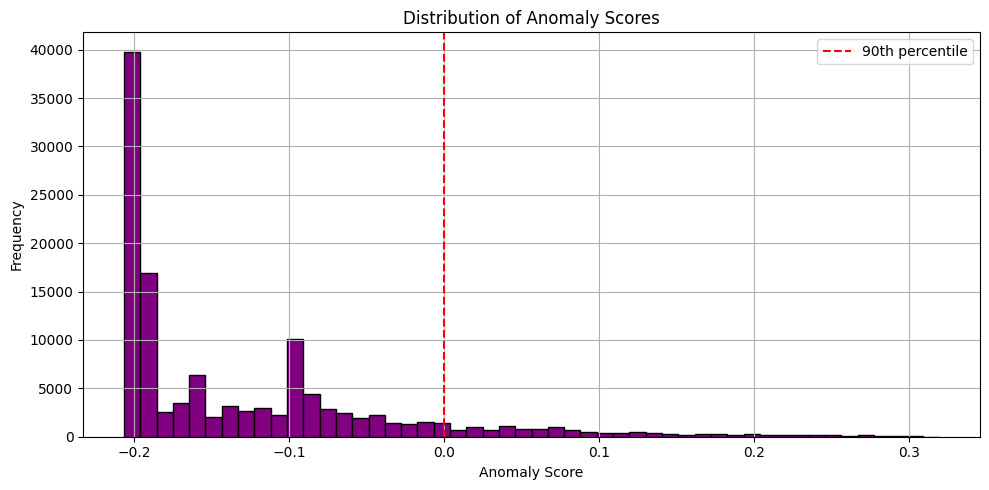

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(df['anomaly_score'], bins=50, color='purple', edgecolor='black')
plt.axvline(df['anomaly_score'].quantile(0.90), color='red', linestyle='--', label='90th percentile')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.title('Distribution of Anomaly Scores')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


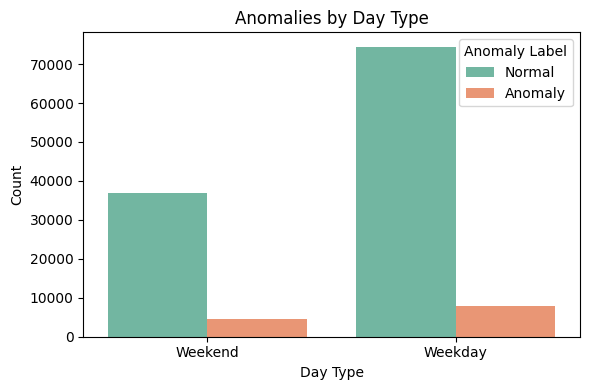

In [6]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='day_type', hue='anomaly_label', palette='Set2')
plt.title('Anomalies by Day Type')
plt.xlabel('Day Type')
plt.ylabel('Count')
plt.legend(title='Anomaly Label', labels=['Normal', 'Anomaly'])
plt.tight_layout()
plt.show()


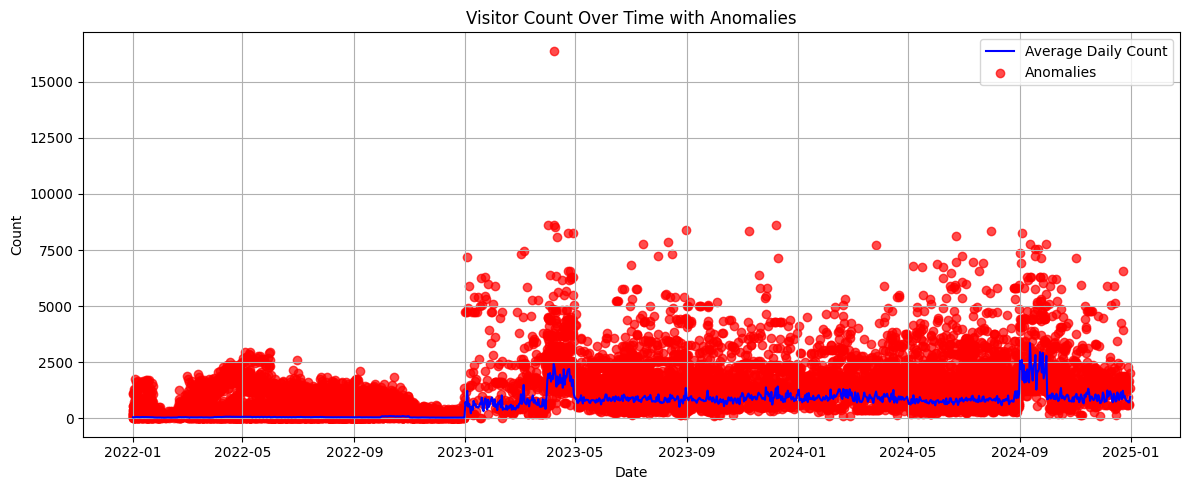

In [7]:
# Daily mean count with anomalies overlaid
daily = df.groupby('date')['count'].mean()

plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily.values, label='Average Daily Count', color='blue')

# Overlay anomalies
anomalies = df[df['anomaly_label'] == 1]
plt.scatter(anomalies['date'], anomalies['count'], color='red', label='Anomalies', alpha=0.7)

plt.title('Visitor Count Over Time with Anomalies')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# ======================
# Step 0: Load & prepare
# ======================
df = pd.read_csv(
    r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv",
    low_memory=False
)

# Clean types
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
df['count'] = pd.to_numeric(df['count'], errors='coerce')
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
df = df.dropna(subset=['date', 'count', 'duration']).copy()

# Calendar features
df['month'] = df['date'].dt.month
df['dow'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['dow'] >= 5).astype(int)

# Add anomaly features
X_ad = StandardScaler().fit_transform(df[['count','duration']])
iso = IsolationForest(contamination=0.10, random_state=42)
pred = iso.fit_predict(X_ad)
score = -iso.decision_function(X_ad)

df['anomaly_label'] = (pred == -1).astype(int)
df['anomaly_score'] = score

# ======================
# Step 1: Train initial model to get feature importances
# ======================
all_features = ['month','dow','is_weekend','duration','anomaly_score','anomaly_label']
X = df[all_features]
y = df['count']

X_train_full, X_test_full, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

initial_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42
)
initial_model.fit(X_train_full, y_train)

# ======================
# Step 2: Select top 5 most important features
# ======================
importances = initial_model.feature_importances_
importance_series = pd.Series(importances, index=all_features).sort_values(ascending=False)
top_features = importance_series.head(5).index.tolist()

print("Top 5 Important Features:", top_features)

# ======================
# Step 3: Retrain model on top features
# ======================
X_top = df[top_features]
X_train, X_test, y_train, y_test = train_test_split(X_top, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
model.fit(X_train, y_train)

# ======================
# Step 4: Evaluate
# ======================
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("\nPerformance Using Top Features Only:")
print("Train R² Score:", round(r2_score(y_train, y_train_pred),4))
print("Test R² Score:",  round(r2_score(y_test, y_test_pred),4))
print("Test MAE:", round(mean_absolute_error(y_test, y_test_pred),3))


Top 5 Important Features: ['anomaly_score', 'duration', 'month', 'dow', 'is_weekend']

Performance Using Top Features Only:
Train R² Score: 0.9991
Test R² Score: 0.9852
Test MAE: 6.6


In [ ]:
# ======================
# Step 2: CLEAN (remove anomalies from training)
# ======================
df_clean = df[df['anomaly_label'] == 0]

X_c = df_clean[all_features]
y_c = df_clean['count']

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42
)

model_clean = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)
model_clean.fit(X_train_clean, y_train_clean)

y_train_pred_clean = model_clean.predict(X_train_clean)
y_test_pred_clean  = model_clean.predict(X_test_clean)

print("\nCLEAN (anomalies removed from training):")
print("Train R²:", round(r2_score(y_train_clean, y_train_pred_clean),4))
print("Test  R²:", round(r2_score(y_test_clean,  y_test_pred_clean),4))
print("Train MAE:", round(mean_absolute_error(y_train_clean, y_train_pred_clean),3))
print("Test  MAE:", round(mean_absolute_error(y_test_clean,  y_test_pred_clean),3))

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor

# ======================
# Step 0: Load & prepare
# ======================
df = pd.read_csv(
    r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv",
    low_memory=False
)

# Clean types
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
df['count'] = pd.to_numeric(df['count'], errors='coerce')
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
df = df.dropna(subset=['date', 'count', 'duration']).copy()

# Calendar features
df['month'] = df['date'].dt.month
df['dow'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['dow'] >= 5).astype(int)

# ======================
# Step A: Anomaly features (same as before)
# ======================
X_ad = StandardScaler().fit_transform(df[['count','duration']])
iso = IsolationForest(contamination=0.10, random_state=42)
pred = iso.fit_predict(X_ad)
score = -iso.decision_function(X_ad)

df['anomaly_label'] = (pred == -1).astype(int)
df['anomaly_score'] = score

# ======================
# Step B: Build feature matrix (ALL NUMERIC FEATURES)
# ======================
# Use every numeric column except the target 'count'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != 'count']

X_all = df[feature_cols].fillna(0)
y = df['count'].values

# Train/val split
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# ======================
# Step C: Initial XGBoost to get importances
# ======================
xgb_full = XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_full.fit(X_train_full, y_train)

# Evaluate with ALL features (optional baseline)
y_train_pred_full = xgb_full.predict(X_train_full)
y_test_pred_full = xgb_full.predict(X_test_full)
print("=== XGBoost (ALL numeric features) ===")
print("Train R²:", round(r2_score(y_train, y_train_pred_full), 4))
print("Test  R²:", round(r2_score(y_test, y_test_pred_full), 4))
print("Test  MAE:", round(mean_absolute_error(y_test, y_test_pred_full), 3))

# ======================
# Step D: Top-10 features by importance
# ======================
importances = xgb_full.feature_importances_
imp_series = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
top10_features = imp_series.head(10).index.tolist()

print("\nTop 10 Important Features (XGBoost):")
for i, f in enumerate(top10_features, 1):
    print(f"{i}. {f}  (score={imp_series[f]:.6f})")

# ======================
# Step E: Retrain XGBoost on TOP-10 features only
# ======================
X_top = df[top10_features].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, random_state=42
)

xgb_top10 = XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_top10.fit(X_train, y_train)

# Evaluate TOP-10 model
y_train_pred = xgb_top10.predict(X_train)
y_test_pred = xgb_top10.predict(X_test)

print("\n=== XGBoost (TOP-10 features) ===")
print("Train R²:", round(r2_score(y_train, y_train_pred), 4))
print("Test  R²:", round(r2_score(y_test, y_test_pred), 4))
print("Test  MAE:", round(mean_absolute_error(y_test, y_test_pred), 3))




=== XGBoost (ALL numeric features) ===
Train R²: 0.9999
Test  R²: 0.9862
Test  MAE: 5.06

Top 10 Important Features (XGBoost):
1. white  (score=0.593428)
2. male_45_49  (score=0.071544)
3. male_35_39  (score=0.037574)
4. female_45_49  (score=0.036043)
5. anomaly_score  (score=0.030550)
6. black  (score=0.029215)
7. female_35_39  (score=0.022473)
8. female_40_44  (score=0.020247)
9. female_5_9  (score=0.018268)
10. female_50_54  (score=0.017868)

=== XGBoost (TOP-10 features) ===
Train R²: 0.999
Test  R²: 0.9816
Test  MAE: 9.64


In [5]:
# ======================
# RandomForestRegressor: ALL features -> importance -> TOP-10 -> retrain
# (Reuses: feature_cols, X_all, X_train_full, X_test_full, y_train, y_test)
# ======================
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# ---- Train RF on ALL numeric features ----
rf_full = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,          # set 20 if you want more regularization
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",     # robust default
    n_jobs=-1,
    random_state=42
)
rf_full.fit(X_train_full, y_train)

# Baseline evaluation (ALL features)
y_train_pred_full_rf = rf_full.predict(X_train_full)
y_test_pred_full_rf  = rf_full.predict(X_test_full)
print("\n=== RandomForest (ALL numeric features) ===")
print("Train R²:", round(r2_score(y_train, y_train_pred_full_rf), 4))
print("Test  R²:", round(r2_score(y_test,  y_test_pred_full_rf), 4))
print("Test  MAE:", round(mean_absolute_error(y_test, y_test_pred_full_rf), 3))

# ---- Top-10 features by importance ----
rf_importances = rf_full.feature_importances_
rf_imp_series = pd.Series(rf_importances, index=feature_cols).sort_values(ascending=False)
rf_top10_features = rf_imp_series.head(10).index.tolist()

print("\nTop 10 Important Features (RandomForest):")
for i, f in enumerate(rf_top10_features, 1):
    print(f"{i}. {f}  (score={rf_imp_series[f]:.6f})")

# ---- Retrain RF on TOP-10 features ----
X_top_rf = X_all[rf_top10_features]
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_top_rf, y, test_size=0.2, random_state=42
)

rf_top10 = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)
rf_top10.fit(X_train_rf, y_train_rf)

# Evaluate TOP-10 model
y_train_pred_rf = rf_top10.predict(X_train_rf)
y_test_pred_rf  = rf_top10.predict(X_test_rf)

print("\n=== RandomForest (TOP-10 features) ===")
print("Train R²:", round(r2_score(y_train_rf, y_train_pred_rf), 4))
print("Test  R²:", round(r2_score(y_test_rf,  y_test_pred_rf), 4))
print("Test  MAE:", round(mean_absolute_error(y_test_rf, y_test_pred_rf), 3))

# Optional: show the top-10 table nicely
print("\nTop-10 importance table:\n",
      rf_imp_series.head(10).reset_index().rename(columns={"index": "feature", 0: "importance"}))



=== RandomForest (ALL numeric features) ===
Train R²: 0.9991
Test  R²: 0.982
Test  MAE: 5.322

Top 10 Important Features (RandomForest):
1. white  (score=0.119718)
2. income_60_75  (score=0.068899)
3. male_45_49  (score=0.064257)
4. female_45_49  (score=0.059436)
5. female_50_54  (score=0.058858)
6. female_55_59  (score=0.051128)
7. female_35_39  (score=0.050003)
8. male_50_54  (score=0.041015)
9. income_75_100  (score=0.035979)
10. male_5_9  (score=0.035897)

=== RandomForest (TOP-10 features) ===
Train R²: 0.9984
Test  R²: 0.9769
Test  MAE: 9.539

Top-10 importance table:
          feature  importance
0          white    0.119718
1   income_60_75    0.068899
2     male_45_49    0.064257
3   female_45_49    0.059436
4   female_50_54    0.058858
5   female_55_59    0.051128
6   female_35_39    0.050003
7     male_50_54    0.041015
8  income_75_100    0.035979
9       male_5_9    0.035897


In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor

# ======================
# Step 0: Load & prepare
# ======================
df = pd.read_csv(
    r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv",
    low_memory=False
)

# Clean types
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
df['count'] = pd.to_numeric(df['count'], errors='coerce')
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
df = df.dropna(subset=['date', 'count', 'duration']).copy()

# Calendar features
df['month'] = df['date'].dt.month
df['dow'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['dow'] >= 5).astype(int)

# ======================
# Step A: Anomaly features (same as before)
# ======================
X_ad = StandardScaler().fit_transform(df[['count','duration']])
iso = IsolationForest(contamination=0.10, random_state=42)
pred = iso.fit_predict(X_ad)
score = -iso.decision_function(X_ad)

df['anomaly_label'] = (pred == -1).astype(int)
df['anomaly_score'] = score

# ======================
# Step B: Build feature matrix (ALL NUMERIC FEATURES)
# ======================
# Use every numeric column except the target 'count'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != 'count']

X_all = df[feature_cols].fillna(0)
y = df['count'].values

# Train/val split
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# ======================
# Step C: Initial XGBoost to get importances
# ======================
xgb_full = XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_full.fit(X_train_full, y_train)

# Evaluate with ALL features (optional baseline)
y_train_pred_full = xgb_full.predict(X_train_full)
y_test_pred_full = xgb_full.predict(X_test_full)
print("=== XGBoost (ALL numeric features) ===")
print("Train R²:", round(r2_score(y_train, y_train_pred_full), 4))
print("Test  R²:", round(r2_score(y_test, y_test_pred_full), 4))
print("Test  MAE:", round(mean_absolute_error(y_test, y_test_pred_full), 3))

# ======================
# Step D: Top-10 features by importance
# ======================
importances = xgb_full.feature_importances_
imp_series = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
top10_features = imp_series.head(10).index.tolist()

print("\nTop 10 Important Features (XGBoost):")
for i, f in enumerate(top10_features, 1):
    print(f"{i}. {f}  (score={imp_series[f]:.6f})")

# ======================
# Step E: Retrain XGBoost on TOP-10 features only
# ======================
X_top = df[top10_features].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, random_state=42
)

xgb_top10 = XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_top10.fit(X_train, y_train)

# Evaluate TOP-10 model
y_train_pred = xgb_top10.predict(X_train)
y_test_pred = xgb_top10.predict(X_test)

print("\n=== XGBoost (TOP-10 features) ===")
print("Train R²:", round(r2_score(y_train, y_train_pred), 4))
print("Test  R²:", round(r2_score(y_test, y_test_pred), 4))
print("Test  MAE:", round(mean_absolute_error(y_test, y_test_pred), 3))

# (Optional) Show the top-10 importance table nicely
top10_table = imp_series.head(10).reset_index()
top10_table.columns = ["feature", "importance"]
print("\nTop-10 importance table:\n", top10_table)


=== XGBoost (ALL numeric features) ===
Train R²: 0.9999
Test  R²: 0.9862
Test  MAE: 5.06

Top 10 Important Features (XGBoost):
1. white  (score=0.593428)
2. male_45_49  (score=0.071544)
3. male_35_39  (score=0.037574)
4. female_45_49  (score=0.036043)
5. anomaly_score  (score=0.030550)
6. black  (score=0.029215)
7. female_35_39  (score=0.022473)
8. female_40_44  (score=0.020247)
9. female_5_9  (score=0.018268)
10. female_50_54  (score=0.017868)

=== XGBoost (TOP-10 features) ===
Train R²: 0.999
Test  R²: 0.9816
Test  MAE: 9.64

Top-10 importance table:
          feature  importance
0          white    0.593428
1     male_45_49    0.071544
2     male_35_39    0.037574
3   female_45_49    0.036043
4  anomaly_score    0.030550
5          black    0.029215
6   female_35_39    0.022473
7   female_40_44    0.020247
8     female_5_9    0.018268
9   female_50_54    0.017868


Weekend Visitors: Friday Evening vs Sat/Sun (May–Aug)
        Friday (Evening)  Saturday (Full day)  Sunday (Full day)
month                                                           
May               327257               527519             536278
June              517736               740561             746087
July              555929               689120             660801
August            406150               629842             423920

Saved summary to: weekend_summary_may_aug.csv


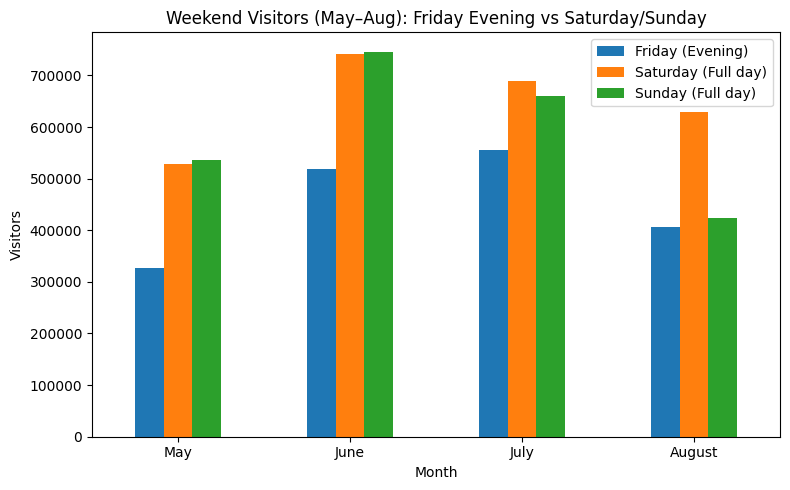

In [4]:
# %%
import pandas as pd
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
CSV_PATH = r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv"
MONTHS_OF_INTEREST = [5, 6, 7, 8]  # May–Aug
EVENING_START_HOUR = 17            # 5 PM
EVENING_HOURS = [f"hh{str(h).zfill(2)}" for h in range(EVENING_START_HOUR, 24)]

# ---------- LOAD ----------
df = pd.read_csv(CSV_PATH, low_memory=False)

# Ensure date is datetime
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce")

# Keep only May–Aug
df = df[df["date"].dt.month.isin(MONTHS_OF_INTEREST)].copy()

# Day-of-week name
df["day_of_week"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.month

# ---------- VALIDATE HOUR COLUMNS ----------
hour_cols = [c for c in df.columns if c.startswith("hh") and len(c) == 4 and c[2:].isdigit()]
missing_evening = [c for c in EVENING_HOURS if c not in hour_cols]
if missing_evening:
    raise ValueError(f"Missing expected hour columns for evening: {missing_evening}")

# ---------- FRIDAY EVENING (5 PM–MIDNIGHT) ----------
is_friday = df["day_of_week"].eq("Friday")
df.loc[is_friday, "friday_evening"] = df.loc[is_friday, EVENING_HOURS].sum(axis=1)

# ---------- FULL-DAY SATURDAY & SUNDAY ----------
sat = df[df["day_of_week"].eq("Saturday")]
sun = df[df["day_of_week"].eq("Sunday")]

# Aggregate by month
fri_eve_by_month = (
    df[df["day_of_week"].eq("Friday")]
    .groupby("month", as_index=True)["friday_evening"]
    .sum()
    .rename("Friday (Evening)")
)
sat_by_month = sat.groupby("month", as_index=True)["count"].sum().rename("Saturday (Full day)")
sun_by_month = sun.groupby("month", as_index=True)["count"].sum().rename("Sunday (Full day)")

# ---------- COMBINE & ORDER ROWS AS May..Aug ----------
summary = pd.concat([fri_eve_by_month, sat_by_month, sun_by_month], axis=1).fillna(0).astype(int)
month_name = {5: "May", 6: "June", 7: "July", 8: "August"}
summary.index = summary.index.map(month_name.get)
summary = summary.loc[["May", "June", "July", "August"]]

# ---------- SAVE & PRINT ----------
out_csv = "weekend_summary_may_aug.csv"
summary.to_csv(out_csv, index=True)

print("Weekend Visitors: Friday Evening vs Sat/Sun (May–Aug)")
print(summary)
print(f"\nSaved summary to: {out_csv}")

# ---------- PLOT (Grouped Bar) ----------
ax = summary.plot(kind="bar", rot=0, figsize=(8, 5))
ax.set_title("Weekend Visitors (May–Aug): Friday Evening vs Saturday/Sunday")
ax.set_xlabel("Month")
ax.set_ylabel("Visitors")
plt.tight_layout()
plt.show()


In [1]:
# %% Simple: 3 anomaly detectors (LOF fixed) -> 3 ML classifiers with extra features
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, average_precision_score, classification_report

# Anomaly detectors
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ===== 1) Load & light prep =====
CSV_PATH = r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv"
df = pd.read_csv(CSV_PATH, low_memory=False)

df["date"] = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce")
df["count"] = pd.to_numeric(df["count"], errors="coerce")
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
df = df.dropna(subset=["date", "count", "duration"]).copy()

df["month"] = df["date"].dt.month
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)

# ===== 2) Ensure supervised label (0/1). If missing, bootstrap with IF on count+duration =====
if "anomaly_label" not in df.columns:
    boot_X = StandardScaler().fit_transform(df[["count", "duration"]])
    lbl_if = IsolationForest(contamination=0.10, random_state=42).fit_predict(boot_X)
    df["anomaly_label"] = (lbl_if == -1).astype(int)

y = df["anomaly_label"].values

# ===== 3) 3 anomaly detectors -> 3 score features =====
detector_cols = ["count", "duration", "month", "dow", "is_weekend"]
X_det = df[detector_cols].fillna(0).copy()
Xs = StandardScaler().fit_transform(X_det)

# 3.1 Isolation Forest (invert so higher=more anomalous)
if_score = -IsolationForest(contamination=0.10, random_state=42).fit(Xs).decision_function(Xs)

# 3.2 LOF with adaptive neighbors to avoid duplicate-tie warning
n = Xs.shape[0]
n_neighbors = min(n - 1, max(75, int(np.sqrt(n)) * 2))  # heuristic
lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=0.10)
_ = lof.fit_predict(Xs)
lof_score = -lof.negative_outlier_factor_

# 3.3 One-Class SVM (invert so higher=more anomalous)
ocsvm_score = -OneClassSVM(kernel="rbf", gamma="scale", nu=0.10).fit(Xs).decision_function(Xs)

# Normalize scores to [0,1]
feature_scores = np.column_stack([if_score, lof_score, ocsvm_score])
feature_scores = MinMaxScaler().fit_transform(feature_scores)

# ===== 4) Build X with detector scores + extra columns =====
extra_cols = ["count", "duration", "month", "dow", "is_weekend"]
extra_cols = [c for c in extra_cols if c in df.columns]

X_extra = df[extra_cols].fillna(0).to_numpy()
X_extra = StandardScaler().fit_transform(X_extra)

# Final feature matrix: [scores | extra features]
X = np.hstack([feature_scores, X_extra])
y = df["anomaly_label"].values

# ===== 5) Split =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ===== 6) Train 3 simple classifiers =====
models = {
    "logreg": LogisticRegression(class_weight="balanced", solver="liblinear", max_iter=1000, random_state=42),
    "rf": RandomForestClassifier(n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=42),
    "gb": GradientBoostingClassifier(random_state=42),
}

print("=== 3 anomaly scores + extra features -> 3 classifiers (LOF fixed) ===")
summary = []
for name, clf in models.items():
    clf.fit(X_train, y_train)
    prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else clf.decision_function(X_test)
    pred = (prob >= 0.5).astype(int)

    p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average="binary", zero_division=0)
    pr_auc = average_precision_score(y_test, prob)

    summary.append((name, p, r, f1, pr_auc))
    print(f"\n{name.upper()}:  P={p:.3f}  R={r:.3f}  F1={f1:.3f}  PR-AUC={pr_auc:.3f}")
    print(classification_report(y_test, pred, digits=4, zero_division=0))

# ===== 7) Simple ranking by PR-AUC =====
summary.sort(key=lambda x: x[-1], reverse=True)
print("\nRanking (by PR-AUC):")
for name, p, r, f1, pr in summary:
    print(f"{name:>6}  PR-AUC={pr:.3f} | F1={f1:.3f} | P={p:.3f} | R={r:.3f}")


=== 3 anomaly scores + extra features -> 3 classifiers (LOF fixed) ===

LOGREG:  P=0.889  R=0.991  F1=0.937  PR-AUC=0.997
              precision    recall  f1-score   support

           0     0.9990    0.9862    0.9926     22254
           1     0.8890    0.9911    0.9373      2472

    accuracy                         0.9867     24726
   macro avg     0.9440    0.9887    0.9649     24726
weighted avg     0.9880    0.9867    0.9871     24726


RF:  P=0.987  R=0.988  F1=0.988  PR-AUC=0.999
              precision    recall  f1-score   support

           0     0.9987    0.9986    0.9987     22254
           1     0.9875    0.9883    0.9879      2472

    accuracy                         0.9976     24726
   macro avg     0.9931    0.9934    0.9933     24726
weighted avg     0.9976    0.9976    0.9976     24726


GB:  P=0.994  R=0.985  F1=0.989  PR-AUC=1.000
              precision    recall  f1-score   support

           0     0.9983    0.9993    0.9988     22254
           1     0.99